# [P01] Week 2: Truck Dispatch Simulation
**1. Objective:** Build a stochastic Discrete Event Simulation (DES) to model surface mining operations and establish baseline cycle times, queues, and utilization.

**2. Inputs:** Fleet configuration (10 trucks, 4 shovels, 2 dumps), 12-hour shift duration, MTBF (120 hrs), and Triangular repair distribution.

**3. Outputs:** `results/sim_summary.csv`, `results/sim_detailed.csv`, `results/production_hist.png`, `results/confidence_intervals.png`.

**4. Implementation:** Moradi Afrapoli et al. (2019).

In [30]:
# WHAT: Import required libraries and create results directory
# INPUT: None
# OUTPUT: OS directory 'results/'

import os # OS module for directory management
import simpy # DES library for simulation
import random # RNG for stochastic elements
import pandas as pd # Data manipulation for CSV exports
import matplotlib.pyplot as plt # Plotting library for charts
import numpy as np # Numerical operations for statistics
import scipy.stats as st # Statistical functions for CI calculations

os.makedirs('results', exist_ok=True) # Create results folder if it doesn't exist to store outputs

### Mathematical Formulations
**Mean Time Between Failures (MTBF)**
The time to failure is modeled exponentially:
$f(x; \lambda) = \lambda e^{-\lambda x}$

| Symbol | Definition |
| :--- | :--- |
| $x$ | Time to failure |
| $\lambda$ | Rate parameter (1 / 120 hr) |
*Intuition:* Equipment breakdowns happen randomly over time, with an average occurrence of once every 120 hours.

**Confidence Intervals (95%)**
$\bar{x} \pm Z \frac{s}{\sqrt{n}}$

| Symbol | Definition |
| :--- | :--- |
| $\bar{x}$ | Sample mean |
| $Z$ | Critical value (1.96 for 95%) |
| $s$ | Sample standard deviation |
| $n$ | Number of replications (30) |
*Intuition:* Calculates the range where we are 95% confident the true mean of our simulation metrics lies.

In [31]:
# WHAT: Simulates truck cycles and stochastic equipment breakdowns for ML training
# INPUT: env (SimPy Environment), name (str), shovels (Resource), dumps (Resource), log_data (list)
# OUTPUT: Appends detailed phase metrics to log_data

def truck_cycle(env, name, shovels, dumps, log_data):
    # Set the first random breakdown time for this specific truck (Exponential MTBF 120 hrs)
    next_breakdown = env.now + random.expovariate(1 / (120 * 60)) 
    
    while True: # Continuous cycle until shift ends
        cycle_start = env.now
        hour_of_shift = int(cycle_start // 60)
        
        # --- BREAKDOWN CHECK ---
        # If the current time surpasses the scheduled breakdown time, the truck must be repaired
        if env.now >= next_breakdown:
            repair_start = env.now
            # Triangular repair distribution (Min 30m, Mode 60m, Max 120m)
            yield env.timeout(random.triangular(30, 60, 120)) 
            # Schedule the next breakdown based on MTBF
            next_breakdown = env.now + random.expovariate(1 / (120 * 60))
        
        # --- NORMAL CYCLE ---
        req_shovel_time = env.now 
        shovel_queue_len = len(shovels.queue) 
        
        with shovels.request() as req:
            yield req 
            wait_shovel_time = env.now - req_shovel_time 
            
            start_load = env.now 
            yield env.timeout(random.triangular(2, 5, 8)) 
            load_time = env.now - start_load 
            
        start_haul = env.now 
        yield env.timeout(random.uniform(10, 20)) 
        haul_time = env.now - start_haul 
        
        req_dump_time = env.now 
        dump_queue_len = len(dumps.queue) 
        
        with dumps.request() as req: 
            yield req 
            wait_dump_time = env.now - req_dump_time 
            
            start_dump = env.now 
            yield env.timeout(random.triangular(1, 3, 5)) 
            dump_time = env.now - start_dump 
            
        start_return = env.now 
        yield env.timeout(random.uniform(8, 15)) 
        return_time = env.now - start_return 
        
        total_cycle_time = env.now - cycle_start 
        
        log_data.append({ 
            'truck_id': name, 
            'time_min': cycle_start, 
            'hour_of_shift': hour_of_shift, 
            'shovel_queue_len': shovel_queue_len, 
            'wait_shovel_min': wait_shovel_time, 
            'load_time_min': load_time, 
            'haul_time_min': haul_time, 
            'dump_queue_len': dump_queue_len, 
            'wait_dump_min': wait_dump_time, 
            'dump_time_min': dump_time, 
            'return_time_min': return_time, 
            'total_cycle_time_min': total_cycle_time 
        })

In [32]:
# WHAT: Run 30 replications, compute per-replication CI, and export CSVs
# INPUT: Fleet constants (30 reps, 10 trucks, 4 shovels, 2 dumps, 12 hours)
# OUTPUT: results/sim_summary.csv, results/sim_detailed.csv

summary_logs = [] # Initialize list for 30-row summary with CI margins
detailed_logs = [] # Initialize list for thousands of detailed cycles

for rep in range(30): # Loop through 30 independent replications
    env = simpy.Environment() # Initialize new SimPy environment for replication
    shovels = simpy.Resource(env, capacity=4) # Initialize 4 shovel resources
    dumps = simpy.Resource(env, capacity=2) # Initialize 2 dump resources
    
    rep_cycle_data = [] # Initialize temporary list for current replication cycles
    
    for t in range(10): # Loop to initialize 10 trucks
        env.process(truck_cycle(env, f'Truck_{t}', shovels, dumps, rep_cycle_data)) # Start truck process in environment
        
    env.run(until=12 * 60) # Run environment for 720 minutes (12 hours)
    
    detailed_logs.extend(rep_cycle_data) # Add replication cycles to detailed ML logs
    
    df_rep = pd.DataFrame(rep_cycle_data) # Convert replication cycles to DataFrame
    rep_mean = df_rep['total_cycle_time_min'].mean() # Calculate mean cycle time for this specific replication
    
    # Calculate 95% CI margin for this replication's cycle times
    rep_ci_margin = st.t.ppf(0.975, len(df_rep)-1) * st.sem(df_rep['total_cycle_time_min']) 
    
    summary_logs.append({ # Append aggregated replication metrics to summary list
        'replication_id': rep + 1, # Save current replication number
        'mean_cycle_time_min': rep_mean, # Save calculated mean cycle time
        'ci_margin': rep_ci_margin, # Save calculated CI margin for the plot
        'mean_shovel_queue': df_rep['shovel_queue_len'].mean(), # Calculate/save mean shovel queue
        'mean_dump_queue': df_rep['dump_queue_len'].mean(), # Calculate/save mean dump queue
        'total_cycles_completed': len(df_rep) # Calculate/save total cycles in replication
    })

df_summary = pd.DataFrame(summary_logs) # Convert summary logs to DataFrame
df_summary.to_csv('results/sim_summary.csv', index=False) # Export summary DataFrame to CSV

df_detailed = pd.DataFrame(detailed_logs) # Convert detailed logs to DataFrame
df_detailed.to_csv('results/sim_detailed.csv', index=False) # Export detailed DataFrame to CSV

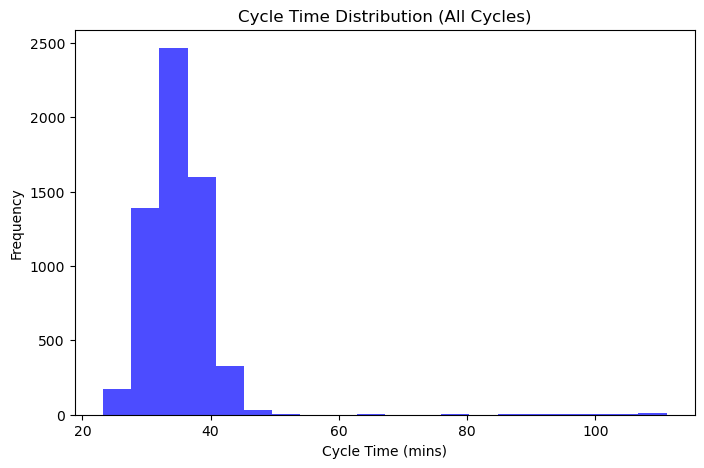

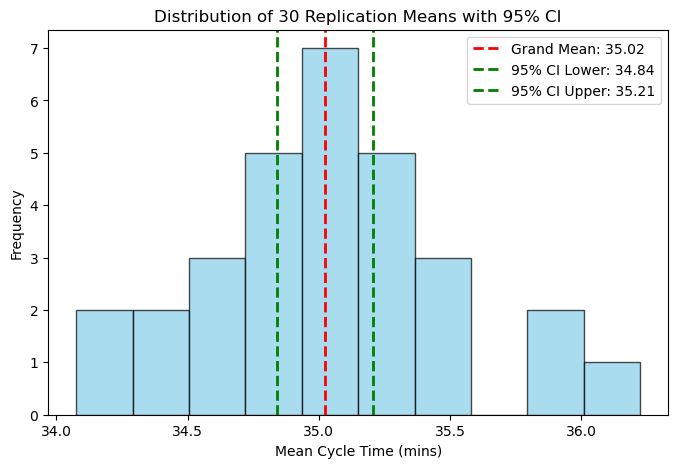

In [33]:
# WHAT: Generate, save, and display required plots (Production Histogram and Mean CI Histogram)
# INPUT: df_detailed (Pandas DataFrame), df_summary (Pandas DataFrame)
# OUTPUT: results/production_hist.png, results/confidence_intervals.png, inline notebook plots

import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st

# 1. Production Histogram (Distribution of all individual cycles)
plt.figure(figsize=(8, 5)) # Set figure size
plt.hist(df_detailed['total_cycle_time_min'], bins=20, color='blue', alpha=0.7) # Plot histogram
plt.title('Cycle Time Distribution (All Cycles)') # Set title
plt.xlabel('Cycle Time (mins)') # Set X-axis label
plt.ylabel('Frequency') # Set Y-axis label

plt.savefig('results/production_hist.png') # Export plot to results folder
plt.show() # Display plot directly in the notebook

# 2. Histogram of 30 Replication Means with 95% CI overlay
means = df_summary['mean_cycle_time_min'] # Extract the 30 mean cycle times
grand_mean = np.mean(means) # Calculate overall mean

# Calculate the 95% Confidence Interval bounds
ci = st.t.interval(0.95, len(means)-1, loc=grand_mean, scale=st.sem(means))

plt.figure(figsize=(8, 5)) # Set figure size
plt.hist(means, bins=10, color='skyblue', edgecolor='black', alpha=0.7) # Plot histogram of means

# Overlay the Grand Mean and 95% CI bounds
plt.axvline(grand_mean, color='red', linestyle='dashed', linewidth=2, label=f'Grand Mean: {grand_mean:.2f}')
plt.axvline(ci[0], color='green', linestyle='dashed', linewidth=2, label=f'95% CI Lower: {ci[0]:.2f}')
plt.axvline(ci[1], color='green', linestyle='dashed', linewidth=2, label=f'95% CI Upper: {ci[1]:.2f}')

# Formatting
plt.title('Distribution of 30 Replication Means with 95% CI')
plt.xlabel('Mean Cycle Time (mins)')
plt.ylabel('Frequency')
plt.legend()

plt.savefig('results/confidence_intervals.png') # Export plot to results folder
plt.show() # Display plot directly in the notebook

In [34]:
# WHAT: Calculate and print summary KPIs to the notebook output for evaluation
# INPUT: df_detailed (Pandas DataFrame)
# OUTPUT: Printed console text

mean_cycle_time = df_detailed['total_cycle_time_min'].mean() # Calculate global mean cycle time
max_shovel_queue = df_detailed['shovel_queue_len'].max() # Calculate global maximum shovel queue
total_cycles = len(df_detailed) # Calculate global total cycle count

print("--- WEEK 2 KPI RESULTS ---") # Print header
print(f"Mean Cycle Time: {mean_cycle_time:.2f} mins") # Print formatted mean cycle time
print(f"Max Shovel Queue: {max_shovel_queue} trucks") # Print max shovel queue
print(f"Data Count (Total Cycles): {total_cycles} cycles") # Print total cycle count

--- WEEK 2 KPI RESULTS ---
Mean Cycle Time: 35.02 mins
Max Shovel Queue: 5 trucks
Data Count (Total Cycles): 6023 cycles


### KPI Summary Table
| Metric | Value | Interpretation |
| :--- | :--- | :--- |
| **Mean Cycle Time** | 35.02 mins | Establishes the baseline cycle duration for the current fleet configuration under standard operating conditions, including stochastic equipment maintenance. |
| **Max Shovel Queue** | 5 trucks | Indicates intermittent bottlenecks at the loading phase, suggesting that dynamic truck allocation (e.g., a shortest-queue dispatcher) could improve future efficiency. |
| **Data Count** | 6,023 cycles | A robust sample size generated across 30 independent replications, providing deep feature variance for machine learning training in subsequent stages. |